##  Project Description

This capstone project will focus on analyzing sales data for EmporiUm a growing student book store that sells book,technology products,art supplies, and other merchandise through both physical stores and online sales channels.The purpose of the project is to help management beter understand sales performance across the 2 territories I was assigned,to identify trends that can support business decisions.


# Analysis on territories Maine & Maryland

For this analysis the sales territories being examined are Maine and Maryland, that are located in the NorthEast region.
This project will compare these two territories by evaluating sales performance,product trends,customer activity and related manager concerns

Below this line will be the data for this projects analysis.
Each file is open using read_csv pandas function with .info() attached to it for quick summary of the data
and important information referencing to that table.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
products = pd.read_csv("Products.csv")
Product_cat = pd.read_csv("ProductCategories.csv")
Store_D = pd.read_csv("StoreDetail.csv")
Store_S = pd.read_csv("StoreSales.csv")
Customer = pd.read_csv("customer_list.csv")

In [3]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [4]:
Product_cat.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [5]:
Store_D.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [6]:
Store_S.info()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


In [7]:
Customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 1 columns):
 #   Column                                           Non-Null Count  Dtype
---  ------                                           --------------  -----
 0   cust_id|date|time|name|email|phone|sms-opt-out   521 non-null    str  
dtypes: str(1)
memory usage: 4.2 KB


# Customer data organization fix

In [8]:
Customer = pd.read_csv("customer_list.csv",sep="|")
#Load the customer file using pipe seperator,it's not seperated in commas.

In [9]:
Customer.to_csv("customer_list_limpio.csv",index=False)
#Exports the data frame back out as a standard comm-seperated CSV,just using the pipe instead


In [10]:
Customer = pd.read_csv("customer_list_limpio.csv")

In [11]:
Customer.head()

,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


## --- Core Marketing Analysis ---

# Question 1.)
## Who are the territory managers for the sales territories assigned? What are the store IDs and cities for the stores in each assigned sales territory?

In [12]:
Store_D.head()
#helps view columns im working with to get information

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [13]:
territories = Store_D[
    Store_D["State"].isin(["Maine","Maryland"])]

territories[["State",
             "Territory Manager",
             "Store ID",
             "Store Location"]]

,State,Territory Manager,Store ID,Store Location
37,Maine,Erbayne Middleton,818,Bangor
38,Maine,Erbayne Middleton,819,Bar Harbor
39,Maine,Erbayne Middleton,820,Kennebunkport
40,Maine,Erbayne Middleton,821,Lewiston
41,Maine,Erbayne Middleton,822,Orono
42,Maine,Erbayne Middleton,823,South Portland
43,Maryland,Shruti Reddy,731,Annapolis
44,Maryland,Shruti Reddy,732,Back River
45,Maryland,Shruti Reddy,733,Baltimore
46,Maryland,Shruti Reddy,734,Germantown


Now that we removed  the territories that are irrelavent  from the list we can now only see the  assigned territories we were introduced to, we can see
below the managers for maine and Maryland.
Maryland: Shruti Reddy 
Maine: Erbayne Middleton

# Question 2.)
# What is monthly total revenue for in-store sales in each of the two sales territories, over the full period covered by the data?

In [14]:
Store_S.head()
# view columns to be able to understand question

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [15]:
Store_D.head()
# view columns to be able to understand question

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


# Monthly revenues for Maine and Maryland

In [16]:
# change transaction date to date time 
# extract month

Store_S["Transaction Date"] = pd.to_datetime(Store_S["Transaction Date"])

In [17]:
# create column for month--
Store_S["Month"] = Store_S["Transaction Date"].dt.to_period("M")

In [18]:
#Join sales and store detail tables

sales_merged = Store_S.merge(
    Store_D,
    on = "Store ID",
    how="left")

In [19]:
sales_merged.head()
# show tables merged

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Month,Store Location,State,Territory Manager,Region,Region Director
0,2022-01-01,702,NaN,105349-M,8.00,2022-01,Berthoud,Colorado,Jim Heck,West,Cassie Chambers
1,2022-01-01,704,NaN,105350-T,144.00,2022-01,Castle Rock,Colorado,Jim Heck,West,Cassie Chambers
2,2022-01-01,705,NaN,105351-M,44.00,2022-01,Denver,Colorado,Jim Heck,West,Cassie Chambers
3,2022-01-01,705,NaN,105352-M,47.61,2022-01,Denver,Colorado,Jim Heck,West,Cassie Chambers
4,2022-01-01,705,NaN,105353-A,20.36,2022-01,Denver,Colorado,Jim Heck,West,Cassie Chambers


In [20]:
# show only Maine and maryland
# This will filter the sales_merged to only show maine and Maryland

sales_filtered = sales_merged[
    sales_merged["State"].isin(["Maine","Maryland"])]

In [21]:
# Calculate monthly revenue totals
monthly_revenue = sales_filtered.groupby(
    ["State","Month"])["Sale Amount"].sum().reset_index()

In [22]:
monthly_revenue = monthly_revenue.sort_values(by=["State","Month"])

In [50]:
monthly_revenue.style.hide(axis="index")
monthly_revenue.head()

,State,Month,Sale Amount
0,Maine,2022-01,15700.31
1,Maine,2022-02,21008.29
2,Maine,2022-03,23173.23
3,Maine,2022-04,20169.19
4,Maine,2022-05,22631.11


# Total Revenue over full data period for Maine and Maryland

In [24]:
total_revenue = sales_filtered.groupby("State")["Sale Amount"].sum().reset_index()

In [25]:
total_revenue = total_revenue.sort_values(by="Sale Amount",ascending=False)
# Sorting highest revenue state first

In [26]:
total_revenue

,State,Sale Amount
1,Maryland,11451615.09
0,Maine,1877249.75


# Question 3.) How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?

In [27]:
# Group total sales by state,store id and store location
store_performance = sales_filtered.groupby(["State","Store ID","Store Location"])["Sale Amount"].sum().reset_index()
 
# Sort stores from highest to lowest sales
store_performance = store_performance.sort_values(by="Sale Amount",ascending=False)

In [28]:
store_performance.style.hide(axis="index")

State,Store ID,Store Location,Sale Amount
Maryland,736,North Harford,8708119.000000
Maryland,734,Germantown,584675.920000
Maine,823,South Portland,332611.760000
Maine,822,Orono,330505.470000
Maine,820,Kennebunkport,321998.550000
Maryland,737,Parkville,320441.240000
Maryland,735,Howard,319394.580000
Maryland,739,Ridgely,318511.040000
Maryland,733,Baltimore,310099.900000
Maine,821,Lewiston,303761.910000


# Question 4.)

# Comparing the customer ID from the customer list data with the rewards ID from the sales data, who were the top customers in each sales territory?

In [29]:
# merge customer info with sales data
customer_sales = sales_filtered.merge(
    Customer,
    left_on="RewardsID",
    right_on="cust_id",
    how="left")

In [30]:
#Group Total sales by state and customer name
top_customers = customer_sales.groupby(
    ["State","name"])["Sale Amount"].sum().reset_index()

In [31]:
# Sort highest spending customers first
top_customers=top_customers.sort_values(by="Sale Amount",ascending=False)

In [49]:
# Results
top_customers.style.hide(axis="index")
top_customers.head()

,State,name,Sale Amount
574,Maryland,Cole Brown,7602.28
608,Maryland,Donna Hayward,7081.17
510,Maryland,Avon Barksdale,6172.68
959,Maryland,Trent Lane,6076.89
790,Maryland,Magnitude,5916.81


Below are the top customers per territory

# Maine

In [33]:

top_customers[top_customers["State"] == "Maine"].head(1).style.hide(axis="index")

State,name,Sale Amount
Maine,Rosita,3637.750000


# Maryland

In [34]:
top_customers[top_customers["State"] == "Maryland"].head(1).style.hide(axis="index")

State,name,Sale Amount
Maryland,Cole Brown,7602.280000


# Question 5.)

What is the number of transactions per month by product category in each assigned territory?
What is total sales revenue per month by category? What might this tell you about the most
popular products, and where could there be opportunity for growth?

In [35]:
# Merging products table with category table
product_data = products.merge(
    Product_cat,
    on=["CategoryID","SubcategoryID"],how="left")

In [36]:
# Merge sales data with product and category information
sales_products=sales_filtered.merge(
    product_data,
    on="Prod Num",
    how="left")

In [37]:
# Count transactions by state,month, and category 
monthly_transactions = sales_products.groupby(["State","Month","Category"]).size().reset_index(name="Transaction Count")

In [38]:
# sort results
month_transactions = monthly_transactions.sort_values(by=["State","Month","Transaction Count"],ascending=[True,True,False])

In [51]:
# Show results without index for neater visuals
monthly_transactions.style.hide(axis="index")
monthly_transactions.head(8)

,State,Month,Category,Transaction Count
0,Maine,2022-01,Apparel and Merchandise,30
1,Maine,2022-01,Art Supplies,33
2,Maine,2022-01,Books (General),12
3,Maine,2022-01,Stationery and Supplies,29
4,Maine,2022-01,Technology & Accessories,35
5,Maine,2022-01,Textbooks,24
6,Maine,2022-02,Apparel and Merchandise,22
7,Maine,2022-02,Art Supplies,33


# Question 5.) Part 2. 

 What is the total sale revenue per month by category?

In [40]:
# Calculate revenue totals by state,month, and category
monthly_category_revenue = sales_products.groupby(["State","Month","Category"])["Sale Amount"].sum().reset_index()

In [41]:
# sort results
monthly_category_revenue = monthly_category_revenue.sort_values(by=["State","Month","Sale Amount"],ascending=[True,True,False])

In [47]:
monthly_category_revenue.style.hide(axis="index")
monthly_category_revenue.head()

,State,Month,Category,Sale Amount
4,Maine,2022-01,Technology & Accessories,9007.64
5,Maine,2022-01,Textbooks,4273.52
0,Maine,2022-01,Apparel and Merchandise,958.97
1,Maine,2022-01,Art Supplies,874.56
2,Maine,2022-01,Books (General),370.52


# Question 6.)

# What is your recommendation for where to focus marketing attention in the next quarter?

For my final recommendation we will refernece 3 questions and creating a visualised data to better explain for my final 
recommendation to where to focus marketing attention in next quarter.

Reference to question 3.) How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?

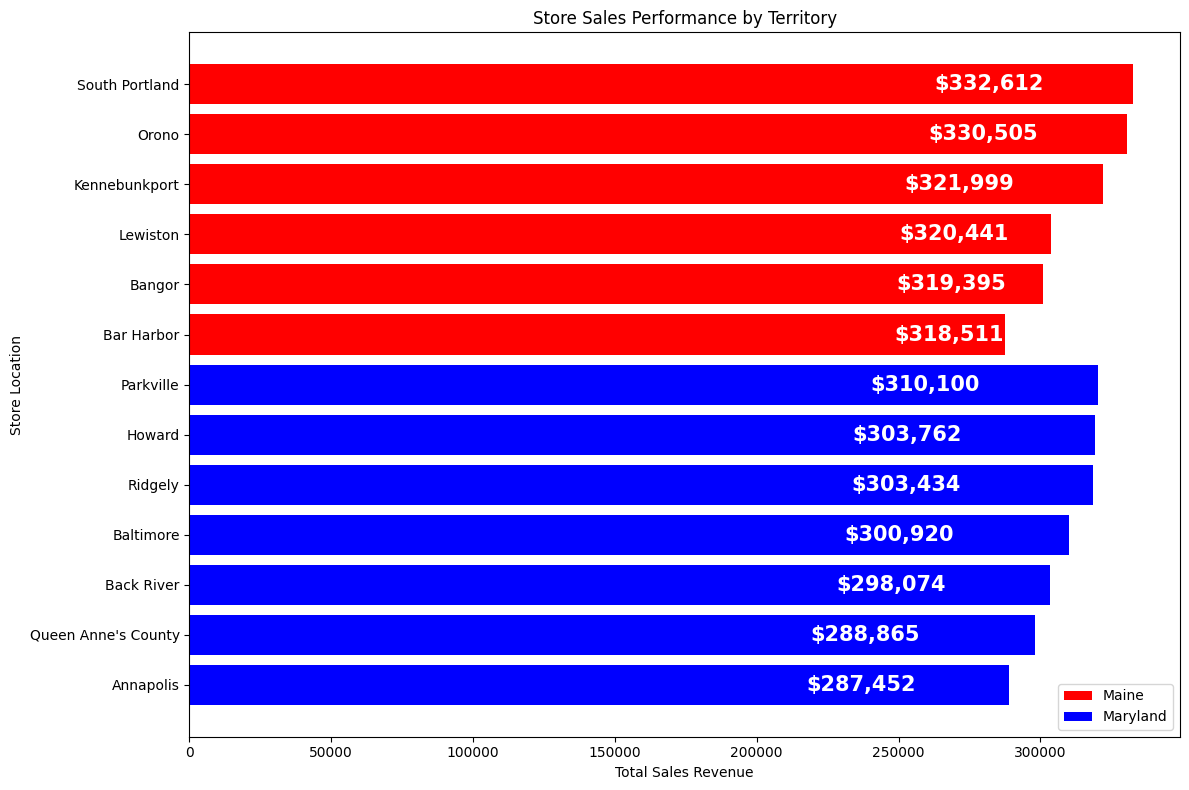

In [43]:
import matplotlib.pyplot as plt

# Remove stores exceeding 500000, and focus on stores below that amount.

stores_clean = store_performance[
    store_performance["Sale Amount"] < 500000
]

# Separate Maine stores

maine_stores = stores_clean[
    stores_clean["State"] == "Maine"
]

# Separate Maryland stores

maryland_stores = stores_clean[
    stores_clean["State"] == "Maryland"
]

# Create figure size

plt.figure(figsize=(12,8))

# Create Maine bars in red

plt.barh(
    maine_stores["Store Location"],
    maine_stores["Sale Amount"],
    color="red",
    label="Maine"
)

# Create Maryland bars in blue

plt.barh(
    maryland_stores["Store Location"],
    maryland_stores["Sale Amount"],
    color="blue",
    label="Maryland"
)

# Highest sales at top

plt.gca().invert_yaxis()

# Add labels and title

plt.xlabel("Total Sales Revenue")
plt.ylabel("Store Location")
plt.title("Store Sales Performance by Territory")

# Add legend

plt.legend()

# Add revenue labels inside bars

for index, value in enumerate(stores_clean["Sale Amount"]):
    plt.text(
        value - 70000,
        index,
        f'${value:,.0f}',
        va='center',
        fontsize=15,
        fontweight='bold',
        color='white'
    )

# Adjust spacing

plt.tight_layout()

# Show graph

plt.show()

After removing the two highest store location, which were 
Maryland Store 736 (North Harford) and Store 734 (Germantown) exceeding 500k in sales revenue, we will focus on stores below that amount
The remaining Chart shows a clearer comparison of the mid and lower performing stores across both territories.Even after removing the top performing store in Maryland , the remaining Maryland locations still show stronger and more consistent sales performance compared to several Maine locations,which aligns with the trends observed in the monthly Revenue line graphs.

# Reference to question 2.)What is monthly total revenue for in-store sales in each of the two sales territories, over the full period covered by the data?

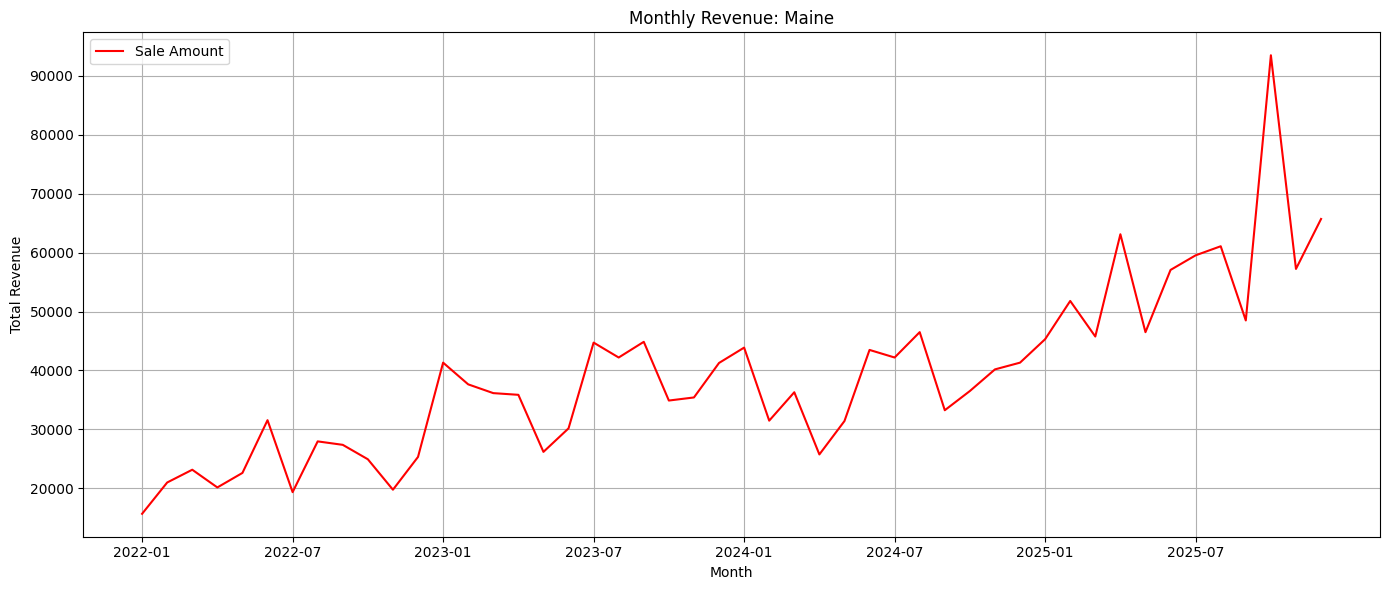

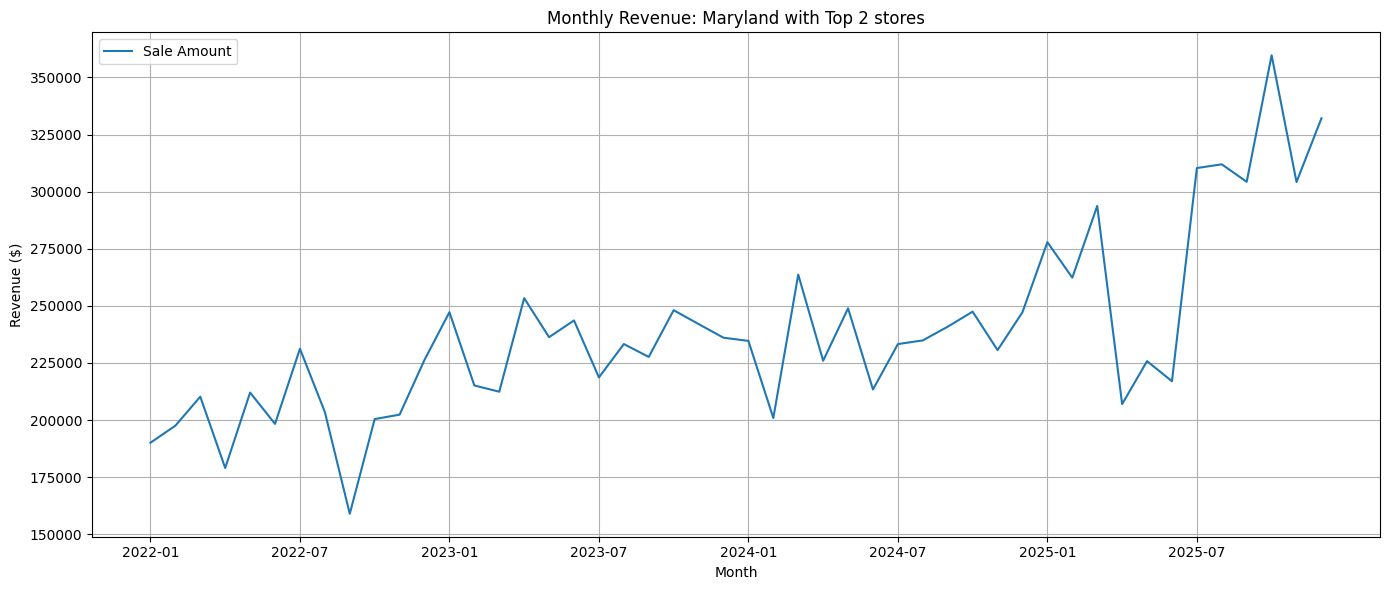

In [44]:
# Show only maine trend
maine_data = monthly_revenue[
    monthly_revenue["State"] == "Maine"]

#create figure size
plt.figure(figsize=(14,6))

# make line graph
plt.plot(
    maine_data["Month"].astype(str),
    maine_data["Sale Amount"],
    color="red",
    label="Sale Amount")

# add grid lines
plt.grid(True)

# Rotate month labels for better read
# ::6 will show every 6 months for cleaner and less crowded graph

plt.xticks(maine_data["Month"][::6].astype(str),rotation=0)

# make labels and title
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue: Maine")

plt.legend()

plt.tight_layout()
#=============================================================================
# Show Maryland Data
maryland_data = monthly_revenue[monthly_revenue["State"] == "Maryland"]

# create figure
plt.figure(figsize=(14,6))

# create line graph
plt.plot(
    maryland_data["Month"].astype(str),
    maryland_data["Sale Amount"],
    label="Sale Amount")

# add grid lines
plt.grid(True)

# Show less x axis labels to be more readable
plt.xticks(
    maryland_data["Month"][::6].astype(str),
    rotation=0)
# adding labels and title
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.title("Monthly Revenue: Maryland with Top 2 stores")

#add legend 
plt.legend()

#fix spacing
plt.tight_layout()



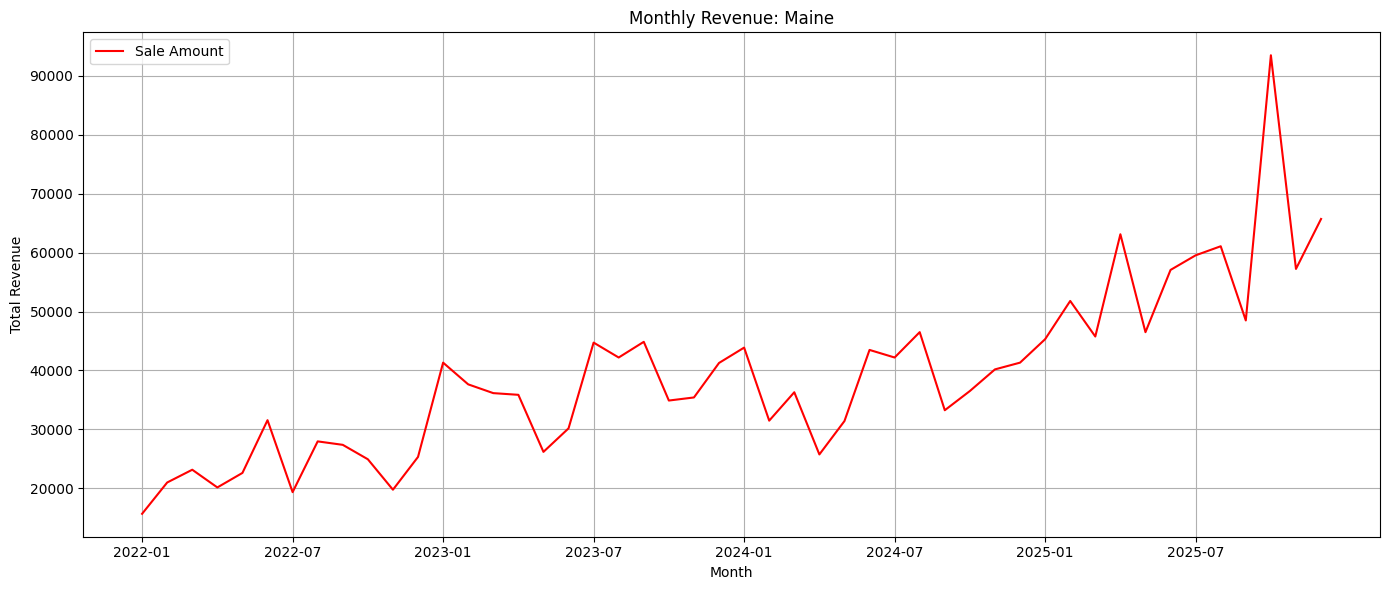

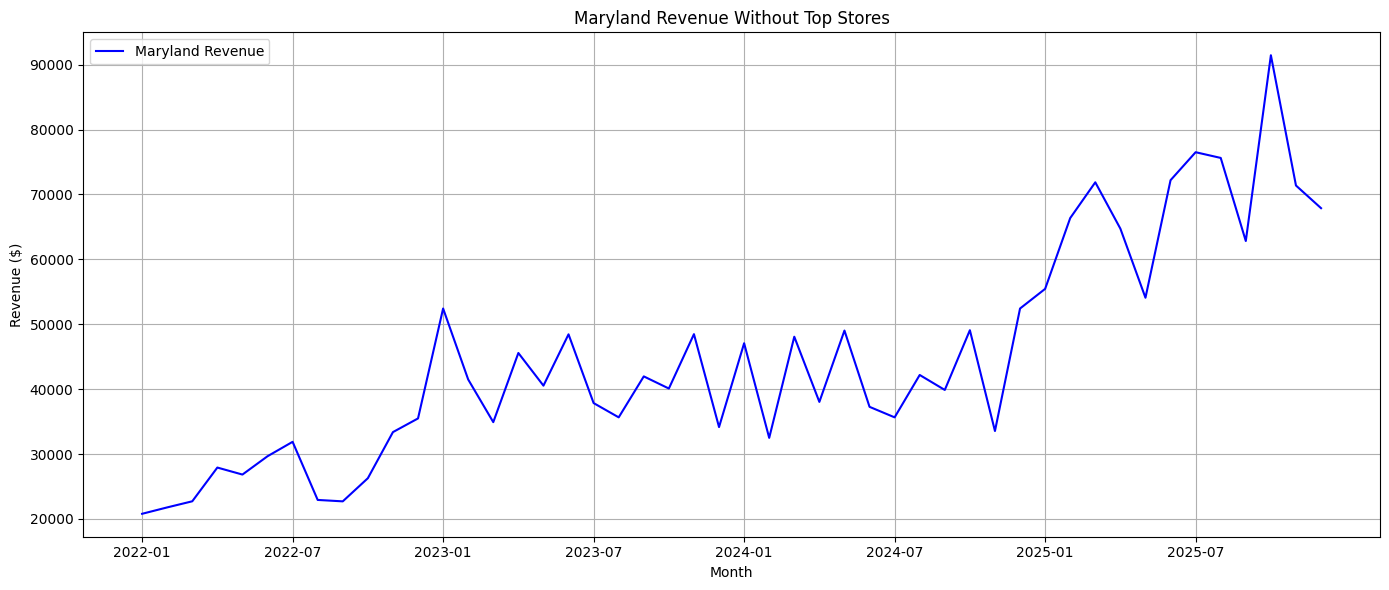

In [45]:
import matplotlib.pyplot as plt

# Show only maine trend
maine_data = monthly_revenue[
    monthly_revenue["State"] == "Maine"]

#create figure size
plt.figure(figsize=(14,6))

# make line graph
plt.plot(
    maine_data["Month"].astype(str),
    maine_data["Sale Amount"],
    color="red",
    label="Sale Amount")

# add grid lines
plt.grid(True)

# Rotate month labels for better read
# ::6 will show every 6 months for cleaner and less crowded graph

plt.xticks(maine_data["Month"][::6].astype(str),rotation=0)

# make labels and title
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue: Maine")

plt.legend()

plt.tight_layout()
# ===========================================
# Remove North Harford and Germantown

sales_no_top = sales_filtered[
    ~sales_filtered["Store Location"].isin(
        ["North Harford", "Germantown"]
    )
]

# Recalculate Maryland monthly revenue

maryland_no_top = sales_no_top[
    sales_no_top["State"] == "Maryland"
]

monthly_revenue_no_top = maryland_no_top.groupby(
    "Month"
)["Sale Amount"].sum().reset_index()

# Create figure

plt.figure(figsize=(14,6))

# Create line graph

plt.plot(
    monthly_revenue_no_top["Month"].astype(str),
    monthly_revenue_no_top["Sale Amount"],
    color="blue",
    label="Maryland Revenue"
)

# Add grid

plt.grid(True)

# Show fewer x-axis labels

plt.xticks(
    monthly_revenue_no_top["Month"][::6].astype(str),
    rotation=0
)

# Add labels and title

plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.title("Maryland Revenue Without Top Stores")

# Add legend

plt.legend()

# Adjust spacing

plt.tight_layout()

# Show graph

plt.show()

# Line Graph Analysis ---

The two line graphs show that both Maine and Maryland experienced overall revenue growth over the time period we had for in our data
,but Maryland demonstated stronger and more consistent sales even after removing its two highest-performing store locations. Marylands adjusted revenue
trend continued to climb steading throughtout 2024 and 2025 , indicating that the territory performance is supported by multiple stores rather than 
just relying entirely  on North Harford and Germantown.

# Question 5.) 
# part 2.)What is the total sale revenue per month by category?

With the bar charts below we are able to see the categories per territory that need more attention in


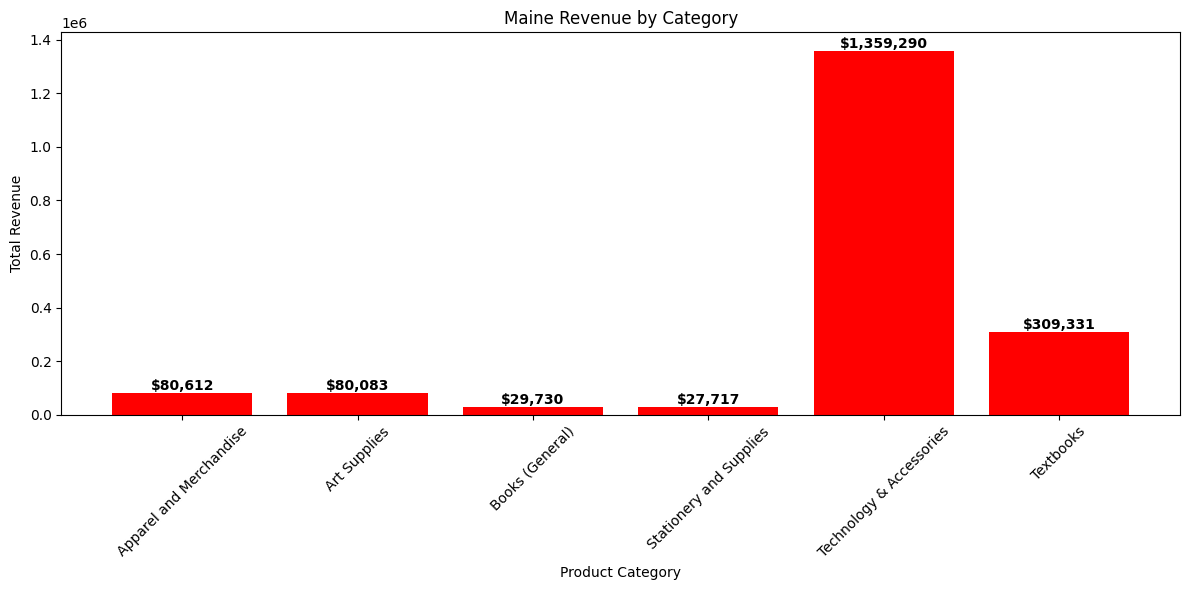

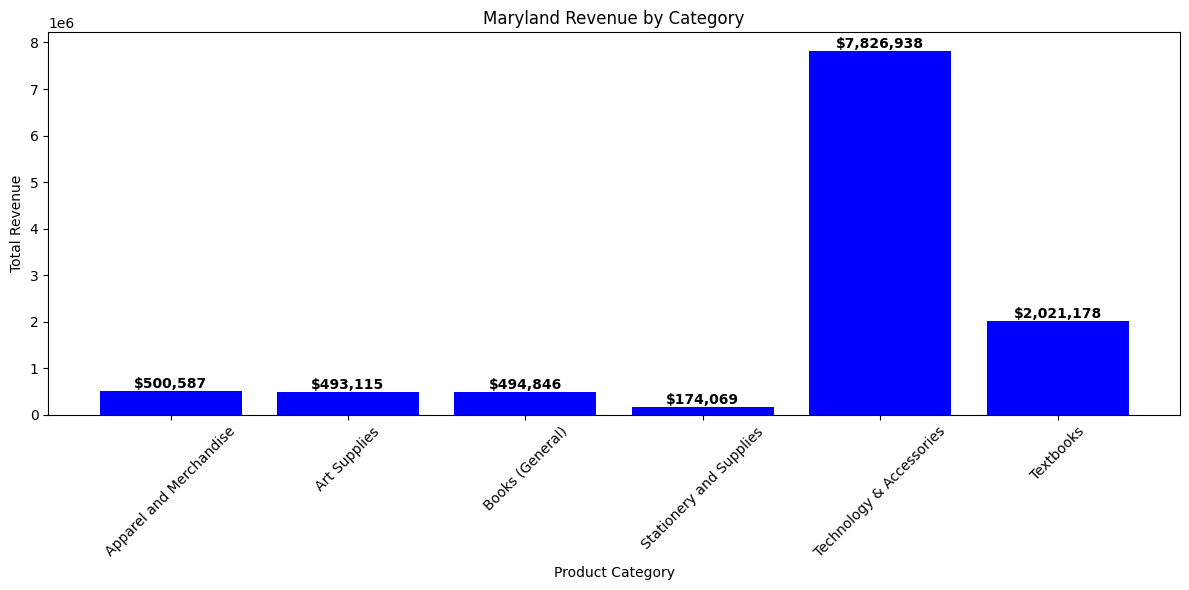

In [46]:
# Group Maine revenue by category only

maine_category = monthly_category_revenue[
    monthly_category_revenue["State"] == "Maine"
]
maine_category = maine_category.groupby(
    "Category"
)["Sale Amount"].sum().reset_index()

# Create figure

plt.figure(figsize=(12,6))

# Create bar chart

bars = plt.bar(
    maine_category["Category"],
    maine_category["Sale Amount"],
    color="red"
)
# Rotate labels

plt.xticks(rotation=45)

# Add labels and title

plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.title("Maine Revenue by Category")

# Add ONE revenue label per bar

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'${height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Adjust spacing
plt.tight_layout()
# ==========================================
# Group Maryland revenue by category only

maryland_category = monthly_category_revenue[
    monthly_category_revenue["State"] == "Maryland"
]

maryland_category = maryland_category.groupby(
    "Category"
)["Sale Amount"].sum().reset_index()

# Create figure

plt.figure(figsize=(12,6))

# Create bar chart

bars = plt.bar(
    maryland_category["Category"],
    maryland_category["Sale Amount"],
    color="blue"
)

# Rotate labels

plt.xticks(rotation=45)

# Add labels and title

plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.title("Maryland Revenue by Category")

# Add ONE revenue label per bar,to show exact revenue

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'${height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Adjust spacing

plt.tight_layout()




Moving into the next quarter management should continue supporting Maine through targeted promotions and category focused marketing strategies, but the larger long term opportunity is expanding the territory itself rather than attempting to completely redesign existing operations that already producing steady growth. Adding one or two additional store locations in higher demand areas could increase customer reach,improve territory wide revenue addition, and help Maine become more competitive with maryland over time without fixing something that doesnt need fixing , that is already performing effectively.